In [2]:
import pandas as pd
import numpy as np

# Data Cleaning

In [3]:
df = pd.read_csv('egypt_real_estate_listings.csv')
features = ['price', 'location', 'type', 'size', 'bedrooms', 'bathrooms']

df_model = df[features]

# Remove entries without a price
df_model = df_model.dropna(subset=['price'], axis=0)
# Remove entries without bedroom values
df_model = df_model.dropna(subset=['bedrooms', 'bathrooms'], axis=0)

In [4]:
# Removing commas from 'price'
df_model['price'] = df_model['price'].str.replace(',', '').astype(float)

In [5]:
# Renaming 'price' to 'price_egp'
# Adding 'price_usd'
pd.set_option('display.float_format', '{:.2f}'.format)
df_model['price_usd'] = df_model['price'] * 0.210172

In [6]:
# Ensuring numeric columns are numeric
# Replacing '7+' values to numerical value 7
df_model['bathrooms'] = df_model['bathrooms'].replace('7+', 7)
df_model = df_model[df_model['bathrooms'] != 'none']
df_model['bathrooms'] = df_model['bathrooms'].astype(float)
df_model['bathrooms'] = df_model['bathrooms'].astype(int)

In [7]:
# Create binary column whether or not house has a maid room 
# (0: no maid room, 1: has maid room)
df_model['maid_room'] = df_model['bedrooms'].str.contains('Maid', case=False, na=True)

In [8]:
# Replace 'studio' with '0', 'studio+ Maid' with '0+ Maid'
df_model['bedrooms'] = df_model['bedrooms'].replace({'studio': '0', 'studio+ Maid': '0+ Maid'})
df_model['bedrooms'] = df_model['bedrooms'].str.split('+').str[0]
df_model['bedrooms'] = df_model['bedrooms'].astype(int)
print('Uniqe bedrooms col: ', df_model['bedrooms'].unique())

Uniqe bedrooms col:  [1 4 2 3 7 5 0 6]


In [9]:
# Only including entries with 'sqft' in 'size' column
# some entries includes sqm 
df_model = df_model[df_model['size'].str.contains('sqft')]

In [10]:
# Only include square footage as it also includes the square meter
df_model['size'] = df_model['size'].str.split('sqft').str[0]

df_model['size'] = df_model['size'].str.replace(',', '')
df_model['size'] = df_model['size'].astype(int)

In [11]:
# dropping outliers based on price
df_model.drop([4410, 15510, 8174], inplace=True)
df_model.drop([14334, 2693, 14774], inplace=True)

outlier = df_model[df_model['price'] == 840000000].index
df_model.drop(index=outlier, inplace=True)

outlier = df_model[df_model['price'] == 650000000].index
df_model.drop(index=outlier, inplace=True)

In [12]:
# limit the listings to under 5000 square feet to be realistic 
df_model = df_model[df_model['size'] <= 5000]
df_model.reset_index(drop=True, inplace=True)

In [13]:
# Return list of features with their types
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18383 entries, 0 to 18382
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      18383 non-null  float64
 1   location   18383 non-null  object 
 2   type       18383 non-null  object 
 3   size       18383 non-null  int64  
 4   bedrooms   18383 non-null  int64  
 5   bathrooms  18383 non-null  int64  
 6   price_usd  18383 non-null  float64
 7   maid_room  18383 non-null  bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 1023.4+ KB
None


In [14]:
print(df_model.head())

        price                                           location       type  \
0  8000000.00       Swan Lake Gouna, Al Gouna, Hurghada, Red Sea     Chalet   
1 25000000.00   Karmell, New Zayed City, Sheikh Zayed City, Giza      Villa   
2 15135000.00              Azha North, Ras Al Hekma, North Coast     Chalet   
3 12652000.00  Taj City, 5th Settlement Compounds, The 5th Se...  Apartment   
4 45250000.00                 Granville, New Capital City, Cairo      Villa   

   size  bedrooms  bathrooms  price_usd  maid_room  
0   732         1          1 1681376.00       True  
1  2368         4          4 5254300.00      False  
2  1270         2          2 3180953.22      False  
3  1787         3          2 2659096.14      False  
4  4306         7          7 9510283.00      False  


In [15]:
# turn 'maid_room' column into binary (from boolean)
df_model['maid_room'] = df_model['maid_room'].astype(int) # True: 1, False: 0
print(df_model.head())

        price                                           location       type  \
0  8000000.00       Swan Lake Gouna, Al Gouna, Hurghada, Red Sea     Chalet   
1 25000000.00   Karmell, New Zayed City, Sheikh Zayed City, Giza      Villa   
2 15135000.00              Azha North, Ras Al Hekma, North Coast     Chalet   
3 12652000.00  Taj City, 5th Settlement Compounds, The 5th Se...  Apartment   
4 45250000.00                 Granville, New Capital City, Cairo      Villa   

   size  bedrooms  bathrooms  price_usd  maid_room  
0   732         1          1 1681376.00          1  
1  2368         4          4 5254300.00          0  
2  1270         2          2 3180953.22          0  
3  1787         3          2 2659096.14          0  
4  4306         7          7 9510283.00          0  


In [16]:
# Return list of features with their types
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18383 entries, 0 to 18382
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      18383 non-null  float64
 1   location   18383 non-null  object 
 2   type       18383 non-null  object 
 3   size       18383 non-null  int64  
 4   bedrooms   18383 non-null  int64  
 5   bathrooms  18383 non-null  int64  
 6   price_usd  18383 non-null  float64
 7   maid_room  18383 non-null  int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 1.1+ MB
None


In [17]:
# Return number of unique locations 
print(f'Number of unique locations: {df_model['location'].unique().size}')

Number of unique locations: 1470


In [18]:
# drop the 'location' feature as there are too many
df_model.drop(columns=['location'], axis=1, inplace=True)

In [19]:
# Return number of unique property types
print(f'Number of unique locations: {df_model['type'].unique().size}')

Number of unique locations: 14


In [20]:
# Drop location feature as there are too many locations
# Consider adding it back for RandomForest, but not for Linear Regression
# Drop type for now
### df_model_dropped = df_model.drop(columns=['location', 'type'], axis=1)

In [21]:
# Strictly speaking RIDGE is to avoid overfitting and LASSO is to reduce the number of predictors
# https://stackoverflow.com/a/28728520/20455962

# Creating the Models 
### Comparing Random Forest Regression and Linear Regression

In [22]:
# print(df_model_dropped.head(10))

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [24]:
# Distribution of types of apartment
# fig, ax = plt.subplots(1, 2, figsize=(15,4))
# ax[0].hist(X['type'])
# ax[0].tick_params(axis='x', labelrotation=90)
# ax[1].scatter(X['type'], y)
# ax[1].tick_params(axis='x', labelrotation=90)
# ax[1].yaxis.get_major_formatter().set_scientific(False)
# fig.suptitle('Apartment Type Distribution')
# plt.show()

In [25]:
print(df_model['type'].value_counts())

type
Apartment          8265
Chalet             3952
Villa              2590
Townhouse          1253
Twin House          751
Duplex              600
Penthouse           557
iVilla              262
Hotel Apartment     101
Cabin                36
Roof                  6
Full Floor            4
Palace                3
Whole Building        3
Name: count, dtype: int64


In [26]:
# Remove entries with type being either Roof, Full Floor, Palace, or Whole Building
# these entries are special and aren't valuated the same as the other types of real estate
df_model.drop(df_model[(df_model['type'] == 'Roof') | (df_model['type'] == 'Full Floor') | (df_model['type'] == 'Palace') |
                  (df_model['type'] == 'Whole Building')].index, inplace=True)
df_model.reset_index(drop=True, inplace=True)

In [27]:
print(df_model['type'].value_counts())

type
Apartment          8265
Chalet             3952
Villa              2590
Townhouse          1253
Twin House          751
Duplex              600
Penthouse           557
iVilla              262
Hotel Apartment     101
Cabin                36
Name: count, dtype: int64


In [28]:
print(df_model.head())

        price       type  size  bedrooms  bathrooms  price_usd  maid_room
0  8000000.00     Chalet   732         1          1 1681376.00          1
1 25000000.00      Villa  2368         4          4 5254300.00          0
2 15135000.00     Chalet  1270         2          2 3180953.22          0
3 12652000.00  Apartment  1787         3          2 2659096.14          0
4 45250000.00      Villa  4306         7          7 9510283.00          0


In [29]:
# Convert 'type' to numerical
# from 1 to 10 based on count (highest count: 1, lowest count: 14)
df_model['type'] = df_model['type'].map({'Apartment': 1, 'Chalet': 2, 'Villa': 3, 'Townhouse': 4,
                      'Twin House': 5, 'Duplex': 6, 'Penthouse': 7, 'iVilla': 8,
                      'Hotel Apartment': 9, 'Cabin': 10})

print(df_model.head())

        price  type  size  bedrooms  bathrooms  price_usd  maid_room
0  8000000.00     2   732         1          1 1681376.00          1
1 25000000.00     3  2368         4          4 5254300.00          0
2 15135000.00     2  1270         2          2 3180953.22          0
3 12652000.00     1  1787         3          2 2659096.14          0
4 45250000.00     3  4306         7          7 9510283.00          0


In [30]:
# Create X, y for features and target
X = df_model.drop(['price', 'price_usd'], axis=1) # features
y = df_model['price'] # target column

In [31]:
print(f'X: {X.shape}\ny:{y.shape}')

X: (18367, 5)
y:(18367,)


In [32]:
# create train test split data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80)

print("Rows and columns of training data X_train:", X_train.shape)
print("Rows and columns of training data y_train:", y_train.shape)

Rows and columns of training data X_train: (14693, 5)
Rows and columns of training data y_train: (14693,)


### Measuring the performance of each model

In [33]:
# for col in X.columns:
#     fig, ax = plt.subplots(1, 2, figsize=(6,3))
#     ax[0].hist(X[col])
#     ax[1].scatter(X[col], y)
#     fig.suptitle(col)
#     plt.show()

#### Linear Regression

In [34]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, confusion_matrix
# mean squared error
# accuracy (lower = more accurate)
lin_train_mse = mean_squared_error(y_train, lin_reg.predict(X_train))
lin_test_mse = mean_squared_error(y_test, lin_reg.predict(X_test))

print(f'Linear Regression Metrics\nTraining MSE: {lin_train_mse}\nTest MSE: {lin_test_mse}')
print('----------------------------------')

# tests 'fit' of model
# lower = better performance 
lin_train_rmse = root_mean_squared_error(y_train, lin_reg.predict(X_train))
lin_test_rmse = root_mean_squared_error(y_test, lin_reg.predict(X_test))

print(f'Training RMSE: {lin_train_rmse}\nTest RMSE: {lin_test_rmse}')
print('----------------------------------')

# variation of depednet variable with independent variable variation
# lower = less variation
lin_train_r2 = r2_score(y_train, lin_reg.predict(X_train))
lin_test_r2 = r2_score(y_test, lin_reg.predict(X_test))

print(f'Training R2: {lin_train_r2}\nTest R2: {lin_test_r2}')
print('----------------------------------')

# mean absolute error
# average of how far off model is from actual values
lin_train_mae = mean_absolute_error(y_train, lin_reg.predict(X_train))
lin_test_mae = mean_absolute_error(y_test, lin_reg.predict(X_test))

print(f'Training MAE: {lin_train_mae}\nTest MAE: {lin_test_mae}')

Linear Regression Metrics
Training MSE: 111920194360438.72
Test MSE: 129535527848361.5
----------------------------------
Training RMSE: 10579234.110295448
Test RMSE: 11381367.573730387
----------------------------------
Training R2: 0.3446474607607839
Test R2: 0.32482861341946956
----------------------------------
Training MAE: 6483878.596046713
Test MAE: 6399082.47279436


In [36]:
# # Display features by importance (descending)

# # Get importance of features
# if hasattr(lin_reg, 'feature_importances_'):
#     feature_importances = lin_reg.feature_importances_
# else:
#     # If the model does not have feature_importances_, continue to the next model
#     print(f"Linear Regression does not support feature importances.")

# # Create DataFrame for easier viewing
# feature_importances_df = pd.DataFrame({'Feature': X_train.columns,
#                                         'Importance': feature_importances})

# # Sort by importance
# feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# # Plot
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Importance', y='Feature', data=feature_importances_df[:5], palette='Set2')
# plt.title('Importance of Features: Linear Regression')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.grid(False)
# plt.show()

#### Random Forest

In [37]:
# Baseline model 
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)
prediction = rf.predict(X_test)

print(f'R2 Score (RandomizedSearchCV): {r2_score(y_test, prediction)}')
print(f'MSE (RandomizedSearchCV): {mean_squared_error(y_test, prediction)}')

R2 Score (RandomizedSearchCV): 0.4776348476150315
MSE (RandomizedSearchCV): 100218769765217.27


In [38]:
from sklearn.model_selection import RandomizedSearchCV
# # Cross validating parametesr for Random Forest Regression model with RandomizedSearchCV

# parameters = {
#     "n_estimators": [10, 20, 50, 100, 500, 1000],
#     "max_depth": [10, 20, 30, 40, 50, None],
#     #"min_samples_split": [2, 5, 10],
#     #"min_samples_leaf": [1, 2, 4],
#     "max_features": ["auto", "sqrt", "log2"],
#     "bootstrap": [True, False], 
# }

# random_search = RandomizedSearchCV(estimator=rf, param_distributions=parameters)

# # Fit the model
# random_search.fit(X_train, y_train)

# # Best hyperparameters
# print("Best Parameters (RandomizedSearchCV):", random_search.best_params_)

In [39]:
rf = RandomForestRegressor(
    n_estimators=1000, 
    max_features='sqrt', 
    max_depth=20, 
    bootstrap=True, 
    random_state=0
)

rf.fit(X_train, y_train)
prediction = rf.predict(X_test)

print(f'R2 Score (RandomizedSearchCV): {r2_score(y_test, prediction)}')
print(f'MSE (RandomizedSearchCV): {mean_squared_error(y_test, prediction)}')

R2 Score (RandomizedSearchCV): 0.48624705473875685
MSE (RandomizedSearchCV): 98566468115763.23


In [40]:
# Only ran once due to long execution time, uncomment to run again

# from sklearn.model_selection import GridSearchCV
# # Cross validating parametesr for Random Forest Regression model with RandomizedSearchCV
# rf = RandomForestRegressor(random_state=0)

# parameters = {
#     "n_estimators": [10, 20, 50, 100, 500, 1000],
#     "max_depth": [10, 20, 30, 40, 50, None],
#     "max_features": ["auto", "sqrt", "log2"],
#     "bootstrap": [True, False]
# }

# grid_search = GridSearchCV(estimator=rf, param_grid=parameters)

# # Fit the model
# grid_search.fit(X_train, y_train)

# # Best hyperparameters
# print("Best Parameters (GridSearchCV):", grid_search.best_params_)

In [41]:
rf = RandomForestRegressor(
    n_estimators=100, 
    max_features='sqrt', 
    max_depth=10, 
    bootstrap=True,
    random_state=0
)

rf.fit(X_train, y_train)
prediction = rf.predict(X_test)

print(f'R2 Score (GridSearchCV): {r2_score(y_test, prediction)}')
print(f'MSE (GridSearchCV): {mean_squared_error(y_test, prediction)}')
print(f'RMSE (GridSearchCV) {root_mean_squared_error(y_test, prediction)}')
print(f'MAE (GridSearchCV): {mean_absolute_error(y_test, prediction)}')

R2 Score (GridSearchCV): 0.4983770536334341
MSE (GridSearchCV): 96239257809088.52
RMSE (GridSearchCV) 9810160.947155174
MAE (GridSearchCV): 5430025.718663


C:\Users\bryan\AppData\Local\Temp\ipykernel_28548\1858187469.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_df[:5], palette='Set2')


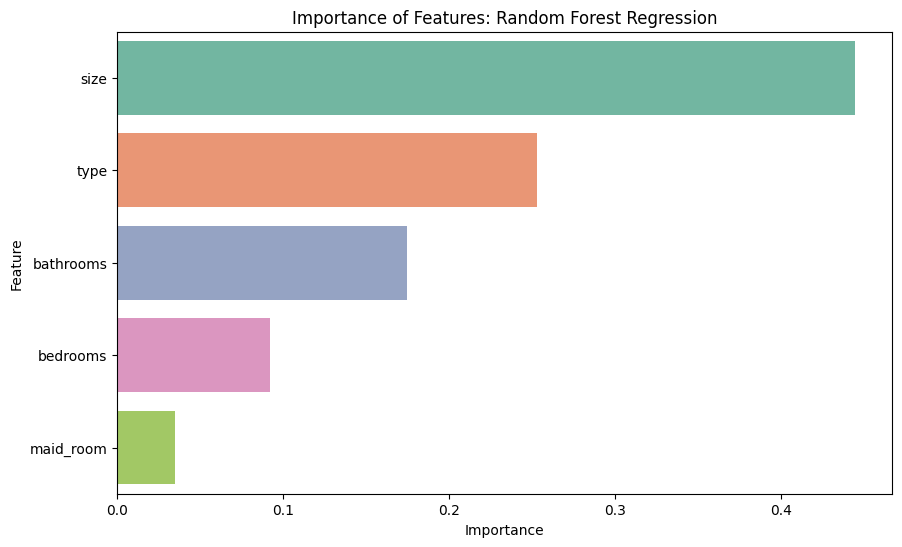

In [42]:
# Display features by importance (descending)

# Get importance of features
if hasattr(rf, 'feature_importances_'):
    feature_importances = rf.feature_importances_
else:
    # If the model does not have feature_importances_, continue to the next model
    print(f"RF does not support feature importances.")

# Create DataFrame for easier viewing
feature_importances_df = pd.DataFrame({'Feature': X_train.columns,
                                        'Importance': feature_importances})

# Sort by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df[:5], palette='Set2')
plt.title('Importance of Features: Random Forest Regression')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(False)
plt.show()

In [43]:
print(feature_importances_df.head())

     Feature  Importance
1       size        0.44
0       type        0.25
3  bathrooms        0.17
2   bedrooms        0.09
4  maid_room        0.03


In [44]:
# Validate model with kfold cv
from sklearn.model_selection import KFold, cross_val_score

# chosen parameters
# rf = RandomForestRegressor(
#     n_estimators=100, 
#     max_features='sqrt', 
#     max_depth=10, 
#     bootstrap=True
# )
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=0)
scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')

average_r2 = np.mean(scores) 
std_r2 = np.std(scores)

print(f"R² Score for each fold: {[round(score, 4) for score in scores]}")
print(f"Average R² across {k} folds: {average_r2:.2f}")
print(f"STD R² across {k} folds: {std_r2:.2f}")

R² Score for each fold: [np.float64(0.4968), np.float64(0.5153), np.float64(0.5104), np.float64(0.466), np.float64(0.4612), np.float64(0.5488), np.float64(0.4614), np.float64(0.4502), np.float64(0.4803), np.float64(0.4738)]
Average R² across 10 folds: 0.49
STD R² across 10 folds: 0.03


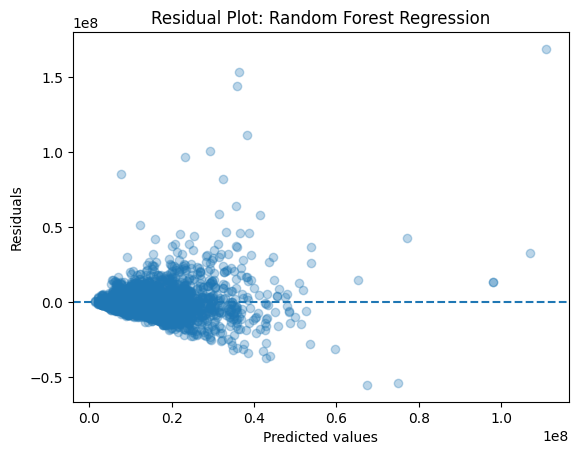

In [45]:
# Residual Plots
residuals = y_test - rf.predict(X_test)

plt.scatter(rf.predict(X_test), residuals, alpha=0.3)
plt.title('Residual Plot: Random Forest Regression')
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.show()

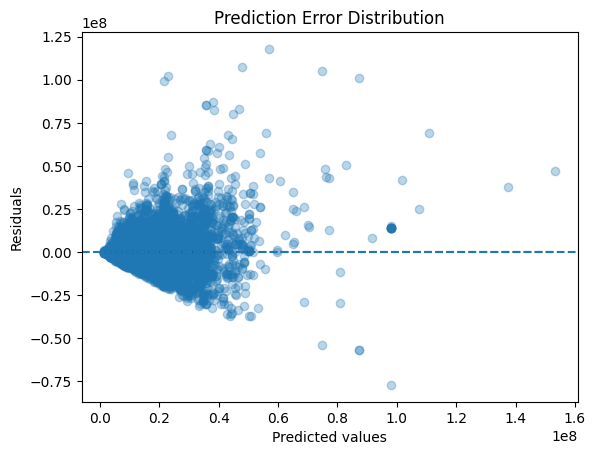

In [46]:
# Prediction Error Distribution
from sklearn.metrics import PredictionErrorDisplay
y_pred = rf.predict(X_train)
pred_error = PredictionErrorDisplay(y_true=y_train, y_pred=y_pred)
pred_error.plot(scatter_kwargs={"alpha": 0.3})
plt.title('Prediction Error Distribution')
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.show()

In [47]:
# # Old; Figuring out hyperparameters manually
# estimators = [10, 20, 50, 100, 500, 1000] # number of trees 
# depths = [None, 5, 10, 20]

# # increase min_sample_leaf if overtfitting
# # increasees the minimal number fo samples required in a leaf node

# # oob_score = regressor.oob_score_

# print('Random Forest Regression Metrics')
# # print(f'Training MAE: {lin_train_mae}\nTest MAE: {lin_test_mae}')

# # loop through estimators and depths to find the best performing combindation
# for estimator in estimators:
#     for depth in depths:
#         ran_for = RandomForestRegressor(n_estimators=estimator, max_depth=depth, random_state=0)
#         ran_for.fit(X_train, y_train)

#         train_pred = ran_for.predict(X_train)
#         test_pred = ran_for.predict(X_test)

#         for_train_mse = mean_squared_error(y_train, train_pred)
#         for_test_mse = mean_squared_error(y_test, test_pred)

#         train_r2 = r2_score(y_train, ran_for.predict(X_train))
#         test_r2 = r2_score(y_test, ran_for.predict(X_test))

#         print(f'Estimator: {estimator} | Depth: {depth}')
#         print(f'Training MSE: {for_train_mse}\nTest MSE: {for_test_mse}')
#         print(f'Training R-Squared Score: {train_r2}\nTest R-Squared Score: {test_r2}')
#         print('----------------------------------')

#### Random Forest - Learning Curve

In [48]:
# Random Forest Learning Curve
from sklearn.model_selection import learning_curve
train_size_abs, train_scores, test_scores = learning_curve(
    rf, X, y, train_sizes=[0.3, 0.6, 0.9]
)

for train_size, cv_train_scores, cv_test_scores in zip(
    train_size_abs, train_scores, test_scores
    ):

    print(f"{train_size} samples were used to train the model")
    print(f"The average train accuracy is {cv_train_scores.mean():.2f}")
    print(f"The average test accuracy is {cv_test_scores.mean():.2f}\n")

4407 samples were used to train the model
The average train accuracy is 0.75
The average test accuracy is 0.34

8815 samples were used to train the model
The average train accuracy is 0.68
The average test accuracy is 0.40

13223 samples were used to train the model
The average train accuracy is 0.62
The average test accuracy is 0.46



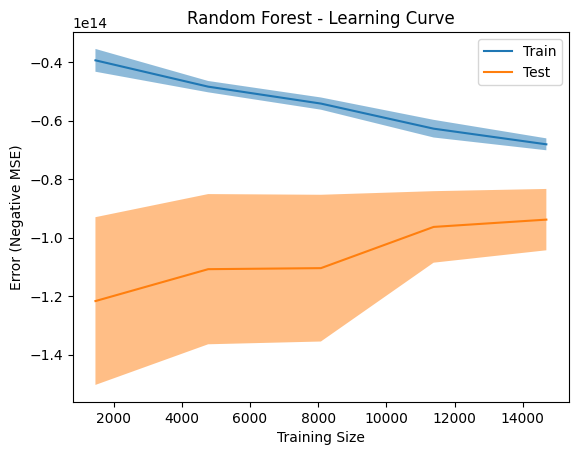

In [49]:
# Random Forest Regression Learning Curve: Training Size vs Error 
from sklearn.model_selection import LearningCurveDisplay, learning_curve
train_sizes, train_scores, test_scores = learning_curve(rf, X, y, scoring='neg_mean_squared_error')

display = LearningCurveDisplay(train_sizes=train_sizes, 
                               train_scores=train_scores, test_scores=test_scores, score_name="Score")

display.plot()
plt.title('Random Forest - Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Error (Negative MSE)')
plt.show()

#### Random Forest Regression - Individual Observations
##### To see what the model gets wrong to analyze and interpret errors

In [50]:
# Display the absolute difference between prediction and actual
rf_pred = rf.predict(X)

d = {"prediction": rf_pred, "actual": y, 'diff': abs(rf_pred - y)}

out = pd.DataFrame(data=d).sort_values(by='diff', ascending=False)

print(out.head(10))

        prediction       actual         diff
388   110962081.91 280000000.00 169037918.09
14526  36219811.73 190000000.00 153780188.27
18156  35798321.61 180000000.00 144201678.39
2165   57124594.22 175000000.00 117875405.78
13607  38302733.78 150000000.00 111697266.22
14629  47768373.68 155000000.00 107231626.32
6467   74914077.09 180000000.00 105085922.91
9745   23063975.17 125000000.00 101936024.83
1414   87115404.62 188135900.00 101020495.38
3779   29260130.58 130000000.00 100739869.42


In [51]:
pd.set_option('display.width', 1000)

i = out.head(10).index.to_list()

print(df_model[df_model.index.isin(i)])

             price  type  size  bedrooms  bathrooms   price_usd  maid_room
388   280000000.00     3  3714         6          7 58848160.00          1
1414  188135900.00     3  4844         6          7 39540898.37          1
2165  175000000.00     3  3929         4          5 36780100.00          1
3779  130000000.00     3  3283         5          6 27322360.00          1
6467  180000000.00     3  4521         6          7 37830960.00          1
9745  125000000.00     3  3229         4          4 26271500.00          1
13607 150000000.00     3  4198         5          6 31525800.00          0
14526 190000000.00     3  3466         5          4 39932680.00          1
14629 155000000.00     3  3821         4          4 32576660.00          1
18156 180000000.00     3  3229         4          3 37830960.00          1


## Visualizations (Interpretation)

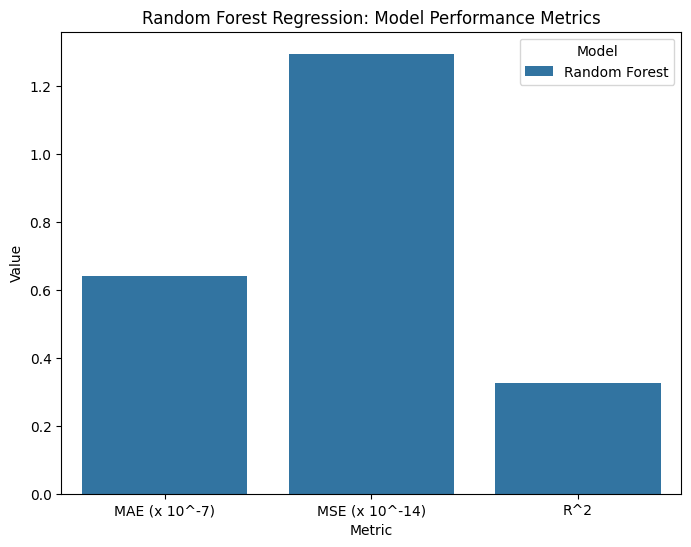

In [52]:
# Model performance metrics (bar plot)
# Compare the performance metrics and plot them
metrics_data = {
    'Model': ['Random Forest', 'Random Forest', 'Random Forest'],
    'Metric': ['MAE (x 10^-7)', 'MSE (x 10^-14)', 'R^2'],
    'Value': [mean_absolute_error(y_test, lin_reg.predict(X_test))/10000000, 
              mean_squared_error(y_test, lin_reg.predict(X_test))/100000000000000, 
              r2_score(y_test, lin_reg.predict(X_test))]
}

df = pd.DataFrame(metrics_data)

# Bar Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=df)
plt.title('Random Forest Regression: Model Performance Metrics')
plt.show()


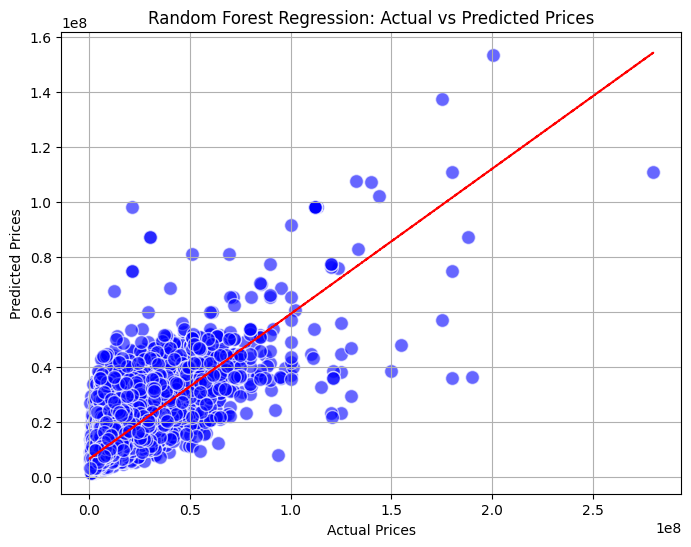

In [53]:
# Compare predictved vs actual prices scatter plot
rf_pred = rf.predict(X)
plt.figure(figsize=(8, 6))

coefficients = np.polyfit(y, rf_pred, 1)
linear_fit_line = np.polyval(coefficients, y)
plt.plot(y, linear_fit_line, color='red', linestyle='--', label='Linear Fit Line')

# Scatter plot
plt.scatter(x=y, y=rf_pred, color='blue', alpha=0.6, edgecolors='w', s=100)

# Labels and title
plt.title('Random Forest Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.grid(True)
plt.show()


In [54]:
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18367 entries, 0 to 18366
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      18367 non-null  float64
 1   type       18367 non-null  int64  
 2   size       18367 non-null  int64  
 3   bedrooms   18367 non-null  int64  
 4   bathrooms  18367 non-null  int64  
 5   price_usd  18367 non-null  float64
 6   maid_room  18367 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 1004.6 KB
None
